# Clinical Labs & Metadata Preprocessing
**Modality:** Clinical labs + canonical subject/sample metadata

Source: `data/raw/sound_life_labs_metadata.csv` (flat; one row per sample visit)
Descriptors: `data/raw/sound_life_clinical_lab_descriptors.csv` (units + reference ranges)
Output: `data/processed/clinical_baseline_wide.csv` (the canonical spine every molecular block joins against)
Manifest: `data/processed/feature_manifest.csv`

This is the **spine**: it defines the baseline sample set and carries the un-prefixed
`subject.*` / `sample.*` metadata and the 3 discrete roots (age group, sex, CMV) that the
whole team joins on, plus the continuous clinical lab panel as `clinical.*` phenotype nodes. Code adapted from clinical_labs_preprocessing.Rmd.

**Design decisions:**
- **Baseline anchor:** `sample.visitName == "Flu Year 1 Day 0"` (92 samples), matching the
  finished olink/cell-freq blocks. `daysSinceFirstVisit == 0` selects a *different* 96-sample
  set (some subjects' first-ever draw is an earlier Immune Variation visit), so we anchor on
  `visitName` and keep an audit flag where the two disagree.
- **Naming:** keep raw dot names (no snake-casing); continuous labs prefixed `clinical.` while
  keeping their group (`chem.alt` -> `clinical.chem.alt`).
- **Roots:** `subject.ageGroup`, `subject.biologicalSex`, `cmv.igg_serology_interpretation`
  used directly as un-prefixed categorical metadata (data has only Negative/Positive CMV — no
  derived column needed).
- **Two flag families:** `_flag_outOfRefRange` (descriptor normal ranges — clinically abnormal,
  NOT an error) vs `_flag_implausible` (physically-impossible values — data errors). These are
  deliberately distinct so normal biological variation is never mislabeled as bad data.
- **No imputation:** flag >20% missing as `exclude_candidate` (keep); drop only 100%-empty cols.

## Stage 0 — Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.io import append_manifest, enforce_export_contract, write_processed
from src.load import load_csv
from src.qc import assert_no_duplicates, flag_missingness

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../figures/preprocessing")
for d in (PROCESSED, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

SUBJ_KEY = "subject.subjectGuid"
SAMPLE_KEY = "sample.sampleKitGuid"
BASELINE_VISIT = "Flu Year 1 Day 0"
DAYS_COL = "sample.daysSinceFirstVisit"
MISS_THRESHOLD = 0.20   # >20% missing => exclude_candidate (flag, never drop)

# Canonical metadata columns the team joins on (kept un-prefixed).
META_COLS = [
    "cohort.cohortGuid", SUBJ_KEY, SAMPLE_KEY,
    "subject.biologicalSex", "subject.birthYear", "subject.ageAtFirstDraw",
    "subject.ageGroup", "subject.race", "subject.ethnicity",
    "sample.visitName", "sample.visitDetails", "sample.drawYear",
    "sample.subjectAgeAtDraw", DAYS_COL, "sample.diseaseStatesRecordedAtVisit",
]
# Categorical lab columns that must NOT be coerced to numeric.
CATEG_LAB_COLS = ["cmv.igg_serology_interpretation",
                  "infl.rf_iga_interpretation", "infl.rf_igm_interpretation"]
# Continuous clinical-feature namespaces (become clinical.* phenotype nodes).
GROUP_PREFIXES = ("am.", "chem.", "bc.", "lip.", "infl.")

## Stage 1 — Ingestion & Standardization

In [2]:
raw = load_csv(RAW / "sound_life_labs_metadata.csv")
desc = pd.read_csv(RAW / "sound_life_clinical_lab_descriptors.csv")

print(f"labs_metadata:  {raw.shape}  (one row per sample visit)")
print(f"descriptors:    {desc.shape}")
print(f"samples:        {raw[SAMPLE_KEY].nunique()}")
print(f"subjects:       {raw[SUBJ_KEY].nunique()}")

# Continuous clinical labs = group-prefixed numeric columns, minus categorical ones.
cont_cols = [c for c in raw.columns
             if c.startswith(GROUP_PREFIXES) and c not in CATEG_LAB_COLS]
print(f"continuous lab columns: {len(cont_cols)}")
raw[[SUBJ_KEY, SAMPLE_KEY, "sample.visitName", DAYS_COL, "subject.ageGroup"]].head()

labs_metadata:  (868, 74)  (one row per sample visit)
descriptors:    (74, 5)
samples:        868
subjects:       96
continuous lab columns: 55


,subject.subjectGuid,sample.sampleKitGuid,sample.visitName,sample.daysSinceFirstVisit,subject.ageGroup
0,BR1001,KT00001,Flu Year 1 Day 0,0,Young Adult
1,BR1002,KT00002,Flu Year 1 Day 0,0,Young Adult
2,BR1003,KT00003,Flu Year 1 Day 0,0,Young Adult
3,BR1004,KT00004,Flu Year 1 Day 0,0,Young Adult
4,BR1005,KT00006,Flu Year 1 Day 0,0,Young Adult


## Stage 2 — Baseline Filtering

Anchor on `sample.visitName == "Flu Year 1 Day 0"`. Keep an audit flag
(`sample.baseline_flag_daysMismatch`) wherever `daysSinceFirstVisit != 0`, so the
disagreement with the plan's literal definition is visible downstream.

In [3]:
baseline = raw[raw["sample.visitName"] == BASELINE_VISIT].copy()

# Audit flag: baseline sample whose daysSinceFirstVisit != 0 (earlier first draw exists).
baseline["sample.baseline_flag_daysMismatch"] = baseline[DAYS_COL] != 0

n_baseline = baseline[SAMPLE_KEY].nunique()
n_mismatch = int(baseline["sample.baseline_flag_daysMismatch"].sum())
print(f"baseline samples (visitName == '{BASELINE_VISIT}'): {n_baseline}")
print(f"baseline subjects: {baseline[SUBJ_KEY].nunique()}")
print(f"daysSinceFirstVisit != 0 (flagged, kept): {n_mismatch}/{n_baseline}")

# One row per subject and per sample; keys non-null (no dedup needed under this anchor).
assert_no_duplicates(baseline, key_cols=[SAMPLE_KEY])
assert_no_duplicates(baseline, key_cols=[SUBJ_KEY])
assert baseline[SAMPLE_KEY].notna().all(), "null sampleKitGuid"
assert baseline[SUBJ_KEY].notna().all(), "null subjectGuid"
print("keys unique + non-null; no duplicate baseline rows.")

baseline samples (visitName == 'Flu Year 1 Day 0'): 92
baseline subjects: 92
daysSinceFirstVisit != 0 (flagged, kept): 32/92
keys unique + non-null; no duplicate baseline rows.


## Stage 3 — Typing, Roots, Derived Features

- Coerce continuous labs to numeric; cast the 3 discrete roots to `category`.
- CMV is used directly (`cmv.igg_serology_interpretation`); assert values stay within
  {Negative, Positive} so future data drift (e.g. an Equivocal) surfaces loudly.
- Unit hygiene: convert height/weight only if the median indicates the wrong unit.
- NLR = neutrophil / lymphocyte (inflammaging marker); guard the zero/NaN denominator.

In [4]:
# --- coerce continuous labs to numeric ---
baseline[cont_cols] = baseline[cont_cols].apply(pd.to_numeric, errors="coerce")

# --- discrete roots -> category ---
baseline["subject.ageGroup"] = pd.Categorical(
    baseline["subject.ageGroup"].str.strip(),
    categories=["Young Adult", "Older Adult"], ordered=True)
baseline["subject.biologicalSex"] = baseline["subject.biologicalSex"].str.strip().astype("category")
baseline["subject.race"] = baseline["subject.race"].str.strip().astype("category")
baseline["subject.ethnicity"] = baseline["subject.ethnicity"].str.strip().astype("category")

# Categorical RF interpretations: kept as un-prefixed clinical context (not BN nodes).
for c in ["infl.rf_iga_interpretation", "infl.rf_igm_interpretation"]:
    baseline[c] = baseline[c].astype("string").str.strip().astype("category")

cmv_vals = set(baseline["cmv.igg_serology_interpretation"].dropna().str.strip().unique())
assert cmv_vals <= {"Negative", "Positive"}, f"unexpected CMV values: {cmv_vals}"
baseline["cmv.igg_serology_interpretation"] = (
    baseline["cmv.igg_serology_interpretation"].str.strip()
    .astype(pd.CategoricalDtype(categories=["Negative", "Positive"])))
print("CMV values:", cmv_vals, "-> used directly (no derived column).")

# --- unit hygiene (height cm, weight kg) ---
med_h = baseline["am.height"].median()
med_w = baseline["am.weight"].median()
if pd.notna(med_h) and med_h < 100:
    print("height looks like inches -> converting to cm")
    baseline["am.height"] = baseline["am.height"] * 2.54
if pd.notna(med_w) and med_w > 200:
    print("weight looks like lbs -> converting to kg")
    baseline["am.weight"] = baseline["am.weight"] / 2.205
print(f"median height={med_h:.1f} cm, median weight={med_w:.1f} kg")

# --- NLR (neutrophil / lymphocyte) ---
lymph = baseline["bc.lymphocyte_count"]
neut = baseline["bc.neutrophil_count"]
undefined = lymph.notna() & (lymph == 0)
baseline["clinical.nlr"] = np.where(lymph.eq(0) | lymph.isna(), np.nan, neut / lymph)
baseline["clinical.nlr_flag_undefined"] = undefined
print(f"NLR undefined (zero lymphocyte denominator): {int(undefined.sum())}")

CMV values: {'Negative', 'Positive'} -> used directly (no derived column).
median height=169.9 cm, median weight=74.8 kg
NLR undefined (zero lymphocyte denominator): 0


## Stage 3b — QC: Two Flag Families (no imputation)

- **`_flag_outOfRefRange`** — value outside the descriptor normal range. *Clinically abnormal,
  not a data error.* eGFR is special: the descriptor lists `< 60`, and clinically eGFR **< 60**
  is the abnormal side (normal is >= 60), so we flag values below 60.
- **`_flag_implausible`** — physically-impossible values: `< 0` for every lab, outside `[0,100]`
  for percentage labs, plus hard physiological ceilings for a targeted set.

Reference ranges / units come from the descriptors file; labs without a descriptor range get no
`outOfRefRange` flag.

In [5]:
import re

def parse_ref_range(s):
    if pd.isna(s):
        return None
    s = str(s).strip()
    m = re.match(r"^(-?\d+(?:\.\d+)?)\s*-\s*(-?\d+(?:\.\d+)?)$", s)
    if m:
        return {"lo": float(m.group(1)), "hi": float(m.group(2)), "kind": "interval"}
    m = re.match(r"^<\s*(-?\d+(?:\.\d+)?)$", s)   # only eGFR: normal is >= threshold
    if m:
        return {"lo": float(m.group(1)), "hi": None, "kind": "lower_normal"}
    return None

ref = {row["column_name"]: pr for _, row in desc.iterrows()
       if (pr := parse_ref_range(row["normal_range_min"])) is not None}
print(f"labs with a parsed reference range: {len(ref)}")

# Percentage labs (>100 physically impossible): descriptor units=='percent' + bc.perc_* by name.
pct_cols = set(desc.loc[desc["units"].astype(str).str.strip().eq("percent"), "column_name"])
pct_cols |= {c for c in cont_cols if c.startswith("bc.perc_")}

# Hard physiological ceilings (impossibility bounds, from the R pipeline).
HARD_CAPS = {
    "bc.neutrophil_count": (500, 20000), "bc.lymphocyte_count": (300, 10000),
    "bc.wbc": (1, 50), "chem.glucose": (30, 600), "lip.cholesterol_total": (50, 500),
    "am.bmi": (10, 80), "am.height": (100, 230), "am.weight": (30, 300),
}

# --- rename continuous labs to clinical.* (keep group), then build flags on the renamed cols ---
rename_map = {c: f"clinical.{c}" for c in cont_cols}
baseline = baseline.rename(columns=rename_map)

flags = {}
for orig in cont_cols:
    col = f"clinical.{orig}"
    val = baseline[col]
    notna = val.notna()
    if orig in ref:
        r = ref[orig]
        if r["kind"] == "interval":
            cond = (val < r["lo"]) | (val > r["hi"])
        else:  # eGFR: abnormal when below the normal threshold
            cond = val < r["lo"]
        flags[f"{col}_flag_outOfRefRange"] = cond.where(notna).astype("boolean")
    imp = (val < 0)
    if orig in pct_cols:
        imp = imp | (val > 100)
    if orig in HARD_CAPS:
        lo, hi = HARD_CAPS[orig]
        imp = imp | (val < lo) | (val > hi)
    flags[f"{col}_flag_implausible"] = imp.where(notna).astype("boolean")

baseline = pd.concat([baseline, pd.DataFrame(flags, index=baseline.index)], axis=1)

n_oor = sum(int((flags[k] == True).sum()) for k in flags if k.endswith("outOfRefRange"))
n_imp = sum(int((flags[k] == True).sum()) for k in flags if k.endswith("implausible"))
print(f"out-of-reference-range flags set (True): {n_oor}")
print(f"implausible flags set (True): {n_imp}")
if n_imp:
    for k, s in flags.items():
        if k.endswith("implausible") and (s == True).any():
            print(f"  {k}: {int((s == True).sum())}")

labs with a parsed reference range: 41


out-of-reference-range flags set (True): 408
implausible flags set (True): 0


## Stage 3c — Missingness Audit (no imputation)

Flag any clinical feature >20% missing as `exclude_candidate` (kept, not dropped — the group
decides imputation jointly). Drop only columns that are 100% empty (zero information).

clinical features: 56
exclude_candidate (>20% missing, kept): 9
  clinical.chem.egfr_aa: 64.1% missing
  clinical.chem.egfr_non_aa: 63.0% missing
  clinical.chem.ldh: 100.0% missing
  clinical.chem.magnesium: 100.0% missing
  clinical.chem.phosphate: 100.0% missing
  clinical.infl.anti_ccp3: 56.5% missing
  clinical.infl.anti_ccp31: 56.5% missing
  clinical.infl.rf_iga_result: 56.5% missing
  clinical.infl.rf_igm_result: 56.5% missing


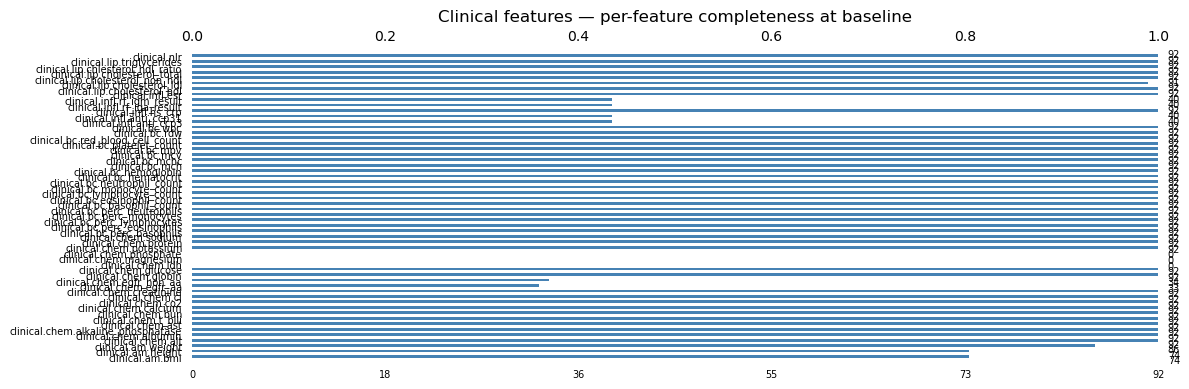


100%-empty columns dropped: ['sample.diseaseStatesRecordedAtVisit', 'clinical.chem.ldh', 'clinical.chem.magnesium', 'clinical.chem.phosphate', 'clinical.chem.ldh_flag_outOfRefRange', 'clinical.chem.ldh_flag_implausible', 'clinical.chem.magnesium_flag_outOfRefRange', 'clinical.chem.magnesium_flag_implausible', 'clinical.chem.phosphate_flag_outOfRefRange', 'clinical.chem.phosphate_flag_implausible']
exclude_candidate features kept in output: 6 -> ['clinical.chem.egfr_aa', 'clinical.chem.egfr_non_aa', 'clinical.infl.anti_ccp3', 'clinical.infl.anti_ccp31', 'clinical.infl.rf_iga_result', 'clinical.infl.rf_igm_result']


In [6]:
feature_cols = [c for c in baseline.columns if c.startswith("clinical.") and "_flag_" not in c]

miss = flag_missingness(baseline[feature_cols], threshold=MISS_THRESHOLD)
exclude_candidates = miss.loc[miss["exclude_candidate"], "feature"].tolist()
print(f"clinical features: {len(feature_cols)}")
print(f"exclude_candidate (>{MISS_THRESHOLD:.0%} missing, kept): {len(exclude_candidates)}")
for f in exclude_candidates:
    print(f"  {f}: {miss.loc[miss.feature == f, 'missing_frac'].iloc[0]:.1%} missing")

fig, ax = plt.subplots(figsize=(12, 4))
msno.bar(baseline[feature_cols], ax=ax, fontsize=7, color="steelblue")
ax.set_title("Clinical features — per-feature completeness at baseline")
plt.tight_layout()
plt.savefig(FIGURES / "clinical_missingness.png", dpi=150)
plt.show()

# Drop only 100%-empty columns (auditable).
empty_cols = [c for c in baseline.columns if baseline[c].notna().sum() == 0]
print(f"\n100%-empty columns dropped: {empty_cols if empty_cols else 'none'}")
baseline = baseline.drop(columns=empty_cols)

# Recompute exclude_candidates on surviving features (partially-missing, kept for the
# group's joint imputation decision) so the audit reflects the post-drop output.
surviving = [c for c in feature_cols if c in baseline.columns]
exclude_candidates = flag_missingness(baseline[surviving], threshold=MISS_THRESHOLD)
exclude_candidates = exclude_candidates.loc[exclude_candidates["exclude_candidate"], "feature"].tolist()
print(f"exclude_candidate features kept in output: {len(exclude_candidates)} -> {exclude_candidates}")

## Stage 4/5 — Assemble & Order

Node set: 3 discrete roots + all `clinical.*` continuous labs + NLR (the plan's ~50-node
already-curated clinical panel — kept, not variance-selected). Column order per the contract:
identifiers -> subject metadata -> sample metadata -> CMV -> clinical features -> all flags last.

In [7]:
id_cols = [SUBJ_KEY, SAMPLE_KEY]
cohort_meta = [c for c in baseline.columns if c.startswith("cohort.")]
subj_meta = [c for c in baseline.columns if c.startswith("subject.") and c not in id_cols and "_flag_" not in c]
samp_meta = [c for c in baseline.columns if c.startswith("sample.") and c not in id_cols and "_flag_" not in c]
cmv_meta = [c for c in baseline.columns if c.startswith("cmv.") and "_flag_" not in c]
feat_cols = sorted(c for c in baseline.columns if c.startswith("clinical.") and "_flag_" not in c)
flag_cols = [c for c in baseline.columns if "_flag_" in c]

# Catch-all: any remaining clinical categorical context columns (e.g. RF interpretations)
# that are neither roots, continuous nodes, nor flags. Kept for context, excluded from nodes.
placed = set(id_cols + cohort_meta + subj_meta + samp_meta + cmv_meta + feat_cols + flag_cols)
other_clin = [c for c in baseline.columns if c not in placed]
if other_clin:
    print(f"clinical context columns (kept, not nodes): {other_clin}")

order = id_cols + cohort_meta + subj_meta + samp_meta + cmv_meta + other_clin + feat_cols + flag_cols
assert set(order) == set(baseline.columns), (
    f"column accounting mismatch: {set(baseline.columns) ^ set(order)}")
wide = baseline[order].reset_index(drop=True)

print(f"assembled spine: {wide.shape}")
print(f"  roots: subject.ageGroup, subject.biologicalSex, cmv.igg_serology_interpretation")
print(f"  clinical feature nodes: {len(feat_cols)}  |  flag columns: {len(flag_cols)}")
wide.head()

clinical context columns (kept, not nodes): ['infl.rf_iga_interpretation', 'infl.rf_igm_interpretation']
assembled spine: (92, 163)
  roots: subject.ageGroup, subject.biologicalSex, cmv.igg_serology_interpretation
  clinical feature nodes: 53  |  flag columns: 92


,subject.subjectGuid,sample.sampleKitGuid,cohort.cohortGuid,subject.biologicalSex,subject.birthYear,subject.ageAtFirstDraw,subject.ageGroup,subject.race,subject.ethnicity,sample.visitName,...,clinical.lip.cholesterol_hdl_flag_implausible,clinical.lip.cholesterol_ldl_flag_outOfRefRange,clinical.lip.cholesterol_ldl_flag_implausible,clinical.lip.cholesterol_non_hdl_flag_outOfRefRange,clinical.lip.cholesterol_non_hdl_flag_implausible,clinical.lip.cholesterol_total_flag_outOfRefRange,clinical.lip.cholesterol_total_flag_implausible,clinical.lip.chlesterol_hdl_ratio_flag_implausible,clinical.lip.triglycerides_flag_outOfRefRange,clinical.lip.triglycerides_flag_implausible
0,BR1001,KT00001,BR1,Female,1987,32,Young Adult,Caucasian,Non-Hispanic origin,Flu Year 1 Day 0,...,False,False,False,False,False,False,False,False,False,False
1,BR1002,KT00002,BR1,Male,1991,28,Young Adult,Caucasian,Non-Hispanic origin,Flu Year 1 Day 0,...,False,False,False,False,False,False,False,False,True,False
2,BR1003,KT00003,BR1,Female,1989,30,Young Adult,Caucasian,Non-Hispanic origin,Flu Year 1 Day 0,...,False,False,False,False,False,False,False,False,False,False
3,BR1004,KT00004,BR1,Male,1989,30,Young Adult,Caucasian,Non-Hispanic origin,Flu Year 1 Day 0,...,False,False,False,False,False,False,False,False,True,False
4,BR1005,KT00006,BR1,Female,1992,27,Young Adult,Caucasian,Non-Hispanic origin,Flu Year 1 Day 0,...,False,False,False,False,False,False,False,False,False,False


## Stage 6 — Export & Manifest

In [8]:
# Validate feature naming via the shared contract on the clinical.* subframe only
# (the spine legitimately carries un-prefixed metadata + roots, so we don't run the
# single-prefix check on the full frame, and we leave shared src/io.py untouched).
clinical_view = wide[id_cols + [c for c in wide.columns if c.startswith("clinical.")]]
enforce_export_contract(clinical_view, prefix="clinical.")

# Metadata / root columns the team joins on must be present.
for c in [SUBJ_KEY, SAMPLE_KEY, "subject.ageGroup", "subject.biologicalSex",
          "cmv.igg_serology_interpretation"]:
    assert c in wide.columns, f"missing required spine column: {c}"
print("export contract (features) + spine metadata checks passed.")

out = write_processed(wide, modality_name="clinical", output_dir=str(PROCESSED))
print(f"written: {out}")

export contract (features) + spine metadata checks passed.
written: ..\data\processed\clinical_baseline_wide.csv


In [9]:
# --- feature manifest: one row per BN node (3 roots + clinical labs + NLR) ---
GROUP_RATIONALE = {
    "am":   "Anthropometric measure (standard clinical assessment); body-composition / metabolic phenotype node.",
    "chem": "Standard clinical blood-chemistry panel (standard-of-care assay); organ-function / metabolic phenotype node.",
    "bc":   "Complete blood count / differential (standard-of-care hematology assay); immune-cell abundance phenotype node.",
    "lip":  "Standard lipid panel (standard-of-care assay); cardiometabolic phenotype node.",
    "infl": "Inflammatory marker (standard clinical assay); systemic-inflammation / inflammaging phenotype node.",
}
ROOT_RATIONALE = {
    "subject.ageGroup": "Discrete root node: chronological age group (Young/Older Adult); upstream driver of immune variation.",
    "subject.biologicalSex": "Discrete root node: biological sex; known modifier of immune phenotype and vaccine response.",
    "cmv.igg_serology_interpretation": "Discrete root node: CMV serostatus; permanent remodeler of immune aging (expanded effector-memory T cells).",
}

entries = []
for c in ["subject.ageGroup", "subject.biologicalSex", "cmv.igg_serology_interpretation"]:
    entries.append({"feature_name": c, "modality": "clinical", "source_column": c,
                    "rationale": ROOT_RATIONALE[c] + " Discrete root; structurally flat prior."})
for c in feat_cols:
    if c == "clinical.nlr":
        entries.append({"feature_name": c, "modality": "clinical",
                        "source_column": "bc.neutrophil_count / bc.lymphocyte_count",
                        "rationale": "Derived neutrophil-to-lymphocyte ratio; established inflammaging marker."})
    else:
        grp = c.split(".")[1]
        entries.append({"feature_name": c, "modality": "clinical", "source_column": c.replace("clinical.", "", 1),
                        "rationale": GROUP_RATIONALE[grp] + " Curated standard panel (not variance-selected); structurally flat prior."})

# Idempotent append: drop any prior clinical rows so re-runs don't duplicate nodes.
manifest_path = PROCESSED / "feature_manifest.csv"
if manifest_path.exists():
    existing = pd.read_csv(manifest_path)
    existing[existing["modality"] != "clinical"].to_csv(manifest_path, index=False)
append_manifest(entries, str(manifest_path))
print(f"manifest entries appended: {len(entries)}")
pd.read_csv(PROCESSED / "feature_manifest.csv").query("modality == 'clinical'").head(8)

manifest entries appended: 56


,feature_name,modality,source_column,rationale
1034,subject.ageGroup,clinical,subject.ageGroup,Discrete root node: chronological age group (Y...
1035,subject.biologicalSex,clinical,subject.biologicalSex,Discrete root node: biological sex; known modi...
1036,cmv.igg_serology_interpretation,clinical,cmv.igg_serology_interpretation,Discrete root node: CMV serostatus; permanent ...
1037,clinical.am.bmi,clinical,am.bmi,Anthropometric measure (standard clinical asse...
1038,clinical.am.height,clinical,am.height,Anthropometric measure (standard clinical asse...
1039,clinical.am.weight,clinical,am.weight,Anthropometric measure (standard clinical asse...
1040,clinical.bc.basophil_count,clinical,bc.basophil_count,Complete blood count / differential (standard-...
1041,clinical.bc.eosinophil_count,clinical,bc.eosinophil_count,Complete blood count / differential (standard-...


In [10]:
# --- final hand-off summary ---
print("=== SPINE HAND-OFF SUMMARY ===")
print(f"rows (baseline samples): {wide.shape[0]}")
print(f"cols (total):            {wide.shape[1]}")
print(f"BN node columns:         {len(feat_cols) + 3}  (3 roots + {len(feat_cols)} clinical)")
print(f"flag columns:            {len(flag_cols)}")
print(f"exclude_candidates:      {len(exclude_candidates)}")
print(f"join keys:               {SUBJ_KEY}, {SAMPLE_KEY}")
print(f"output:                  {out}")

=== SPINE HAND-OFF SUMMARY ===
rows (baseline samples): 92
cols (total):            163
BN node columns:         56  (3 roots + 53 clinical)
flag columns:            92
exclude_candidates:      6
join keys:               subject.subjectGuid, sample.sampleKitGuid
output:                  ..\data\processed\clinical_baseline_wide.csv
